# Housing Prices Competition using Random Forest Regressor

Authors:
1. **Liam Larry Luna**
2. **Harold Tacastacas**

Editor: **Earl Peter J. Gangoso**

Date: June 20, 2024

----

**Competition and Dataset Description:**

The Ames Housing dataset was compiled by Dean De Cock for use in data science education. With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home. This competition allows you to practice creative feature engineering and advanced regression techniques like random forest and gradient boosting.

For detailed description of the data fields, see `data_description.txt`.

**Objectives:**

1. Perform exploratory data analysis to analyze the Ames Housing dataset and its key attributes.
2. Identify important features influencing house prices and create new engineered features.
3. Demonstrate techniques for handling missing values and encoding categorical features.
4. Train a Random Forest Regressor with hyperparameter tuning using Grid Search.





## 1. Exploratory Data Analysis

In [166]:
import pandas as pd

train = pd.read_csv("train.csv")
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [167]:
# Describe the dataset's numerical columns
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


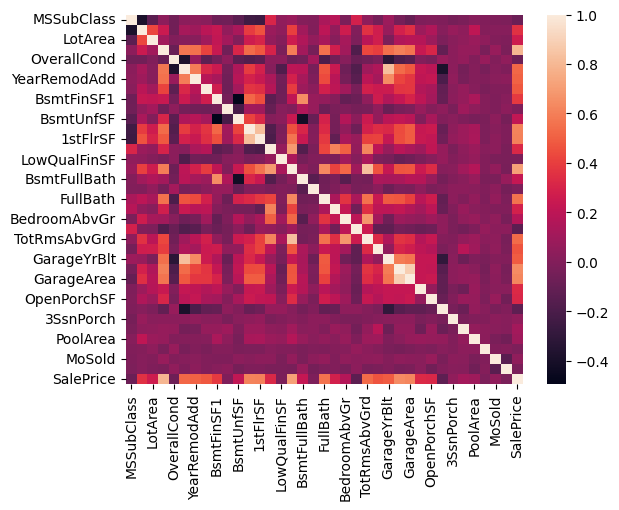

In [168]:
# Show correlation map between numerical features
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(train.select_dtypes(include='number').drop(columns=['Id']).corr())
plt.show()

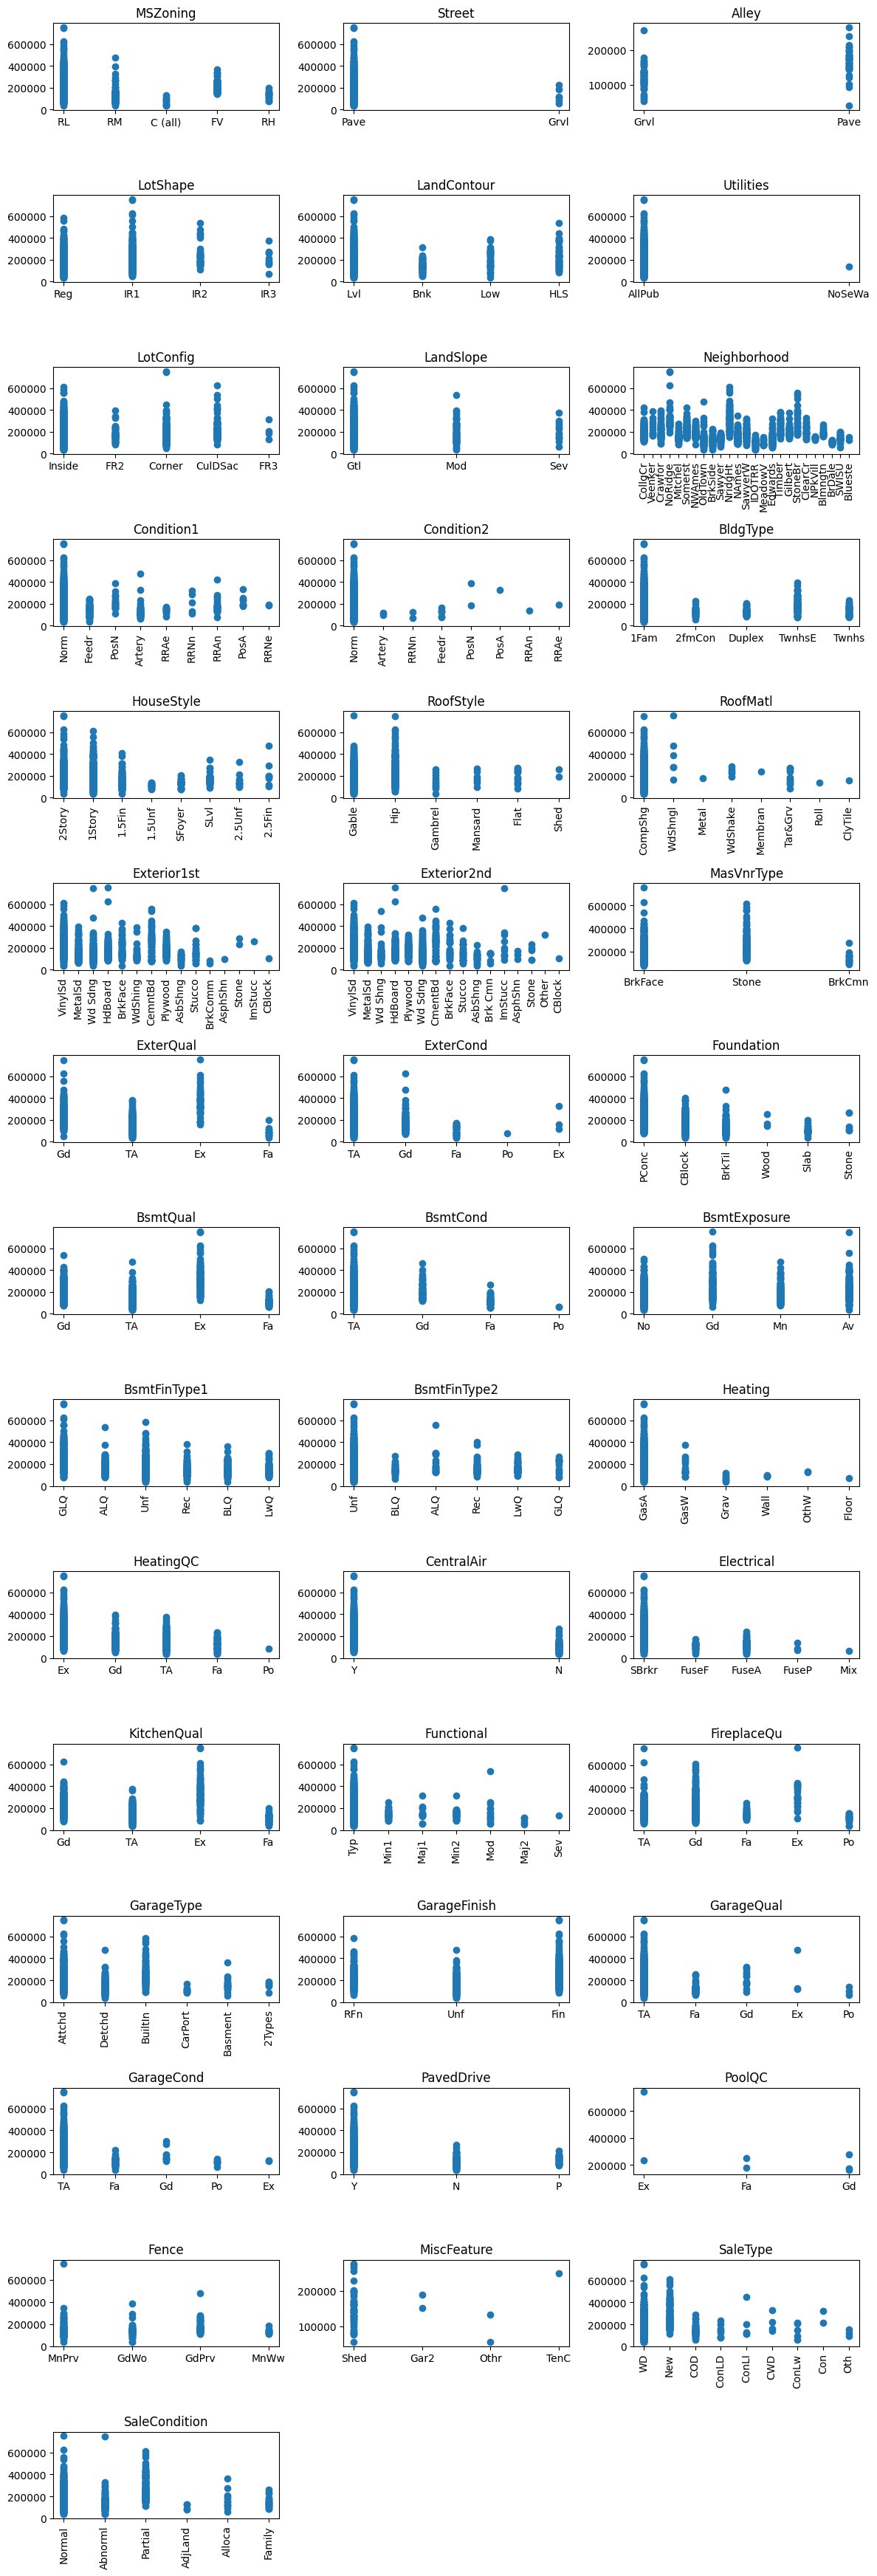

In [169]:
# Show correlation between categorical features and sale price
import math

columns = train.select_dtypes(exclude='number').columns

plt.figure(figsize=(12, 35))

for i, column in enumerate(columns):
    plt.subplot(math.ceil(len(columns) / 3), 3, i + 1)
    plt.title(column)

    df = train[[column, 'SalePrice']].dropna()
    plt.scatter(df[column] , df['SalePrice'])

    if len(df[column].unique()) > 5:
        plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [170]:
# Check if we have missing values in the dataset
missing_values = {col: train[col].isnull().sum() for col in train.columns if train[col].isnull().sum() > 0}
pd.DataFrame(missing_values.items(), columns=["Column", "Number of Missing Values"])

,Column,Number of Missing Values
0,LotFrontage,259
1,Alley,1369
2,MasVnrType,872
3,MasVnrArea,8
4,BsmtQual,37
5,BsmtCond,37
6,BsmtExposure,38
7,BsmtFinType1,37
8,BsmtFinType2,38
9,Electrical,1


## 2. Feature Engineering

In [171]:
def perform_feature_engineering(train):
    df = pd.DataFrame()

    # 2.1. Size-Based Features
    df['TotalBathrooms'] = train['FullBath'] + train['HalfBath'] + train['BsmtFullBath'] + train['BsmtHalfBath']
    # Total square footage
    df['TotalSF'] = train['GrLivArea'] + train['TotalBsmtSF'] + train['GarageArea']

    # 2.2 Quality-Based Features
    # OverallQualityScore = Combine OverallQual & OverallCond
    df['OverallQualityScore'] = train['OverallQual'] * train['OverallCond']
    # LuxuryScore = Evaluate high-value amenities (Fireplaces + PoolArea + GarageCars).
    df['LuxuryScore'] = train['Fireplaces'] + train['PoolArea'] + train['GarageCars']

    # 2.3 Neighborhood & Location Factors
    # Consider if the house is near a main road.
    df['IsNearMainRoad'] = train['Street'].apply(lambda x: 1 if x == 'Pave' else 0)
    # Consider if the house is in a good neighborhood (either 'NoRidge', 'StoneBr', or 'Timber').
    df['IsGoodNeighborhood'] = train['Neighborhood'].apply(lambda x: 1 if x in ['NoRidge', 'StoneBr', 'Timber'] else 0)

    # 2.4. Age Features
    df['HouseAge'] = train['YrSold'] - train['YearBuilt']
    df['RenovationAge'] = train['YrSold'] - train['YearRemodAdd']

    # 2.5. Interaction Features
    # GarageToLotRatio = Garage area vs lot size (GarageArea / LotArea).
    df['GarageToLotRatio'] = train['GarageArea'] / train['LotArea']
    # BasementUsageRatio = Basement livability (TotalBsmtSF / GrLivArea).
    df['BasementUsageRatio'] = train['TotalBsmtSF'] / train['GrLivArea']

    return df

new_features = perform_feature_engineering(train)
new_features

,TotalBathrooms,TotalSF,OverallQualityScore,LuxuryScore,IsNearMainRoad,IsGoodNeighborhood,HouseAge,RenovationAge,GarageToLotRatio,BasementUsageRatio
0,4,3114,35,2,1,0,5,5,0.064852,0.500585
1,3,2984,48,3,1,0,31,31,0.047917,1.000000
2,4,3314,35,3,1,0,7,6,0.054044,0.515118
3,2,3115,35,4,1,0,91,36,0.067225,0.440303
4,4,4179,40,4,1,1,8,8,0.058626,0.520928
...,...,...,...,...,...,...,...,...,...,...
1455,3,3060,30,3,1,0,8,7,0.058103,0.578628
1456,3,4115,36,4,1,0,32,22,0.037951,0.743849
1457,2,3744,63,3,1,0,69,4,0.027870,0.492308
1458,2,2396,30,1,1,0,60,14,0.024699,1.000000


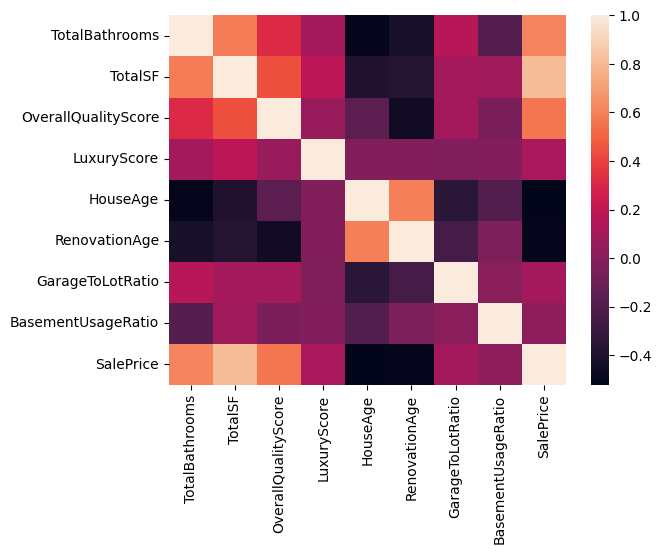

In [172]:
# Show correlation map between new features and SalePrice
new_features['SalePrice'] = train['SalePrice']
sns.heatmap(new_features.drop(columns=['IsNearMainRoad', 'IsGoodNeighborhood']).corr())
plt.show()

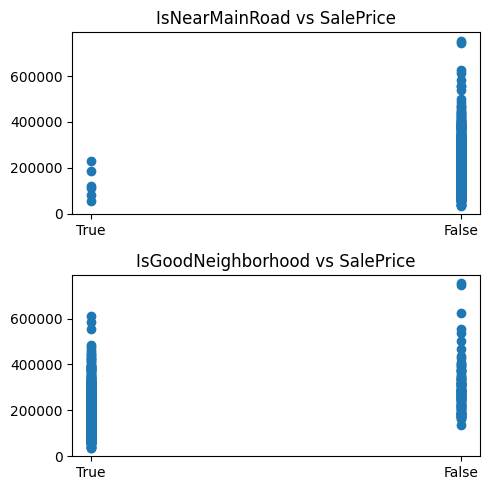

In [173]:
# Show correlation map between new features and SalePrice
plt.figure(figsize=(5, 5))

plt.subplot(2, 1, 1)
plt.scatter(new_features['IsNearMainRoad'], new_features['SalePrice'])
plt.title('IsNearMainRoad vs SalePrice')
plt.xticks([0, 1], ['True', 'False'])

plt.subplot(2, 1, 2)
plt.scatter(new_features['IsGoodNeighborhood'], new_features['SalePrice'])
plt.title('IsGoodNeighborhood vs SalePrice')
plt.xticks([0, 1], ['True', 'False'])

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

The following preprocessing steps involved are:

1. Apply KNN imputation to fill missing numerical values based on similar data points.
2. Convert categorical values into numerical representations using LabelEncoder. Unknown categories default to -1 for handling new or unseen data.
3. Combine newly engineered features into the DataFrame.
5. Remove irrelevant columns, specifically Id, YearBuilt, YrSold, and YearRemodAdd.

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# This will hold our dictionary of label encoders for reuse
les = {}

def preprocess_data(train: pd.DataFrame) -> pd.DataFrame:
    df = train.copy()

    # Append newly engineered features to the DataFrame
    new_features = perform_feature_engineering(df)

    # Perform label encoding for non-numerical columns
    global les
    for col in df.select_dtypes(exclude='number').columns:
        if col in les:
            le = les[col]
            le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
            # Default to -1 for unknown categories
            df[col] = df[col].apply(lambda x: le_dict.get(x, -1))
        else:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            les[col] = le

    df = pd.concat([df, new_features], axis=1)

    # Apply the KNNImputer only to the numerical columns
    knn_imputer = KNNImputer(n_neighbors=5)
    df_imputed = knn_imputer.fit_transform(df)
    df = pd.DataFrame(df_imputed, columns=df.columns)

    # Drop unnecessary columns
    return df.drop(columns=['Id', 'YearBuilt', 'YrSold', 'YearRemodAdd'])

new_train = preprocess_data(train)
new_train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,TotalBathrooms,TotalSF,OverallQualityScore,LuxuryScore,IsNearMainRoad,IsGoodNeighborhood,HouseAge,RenovationAge,GarageToLotRatio,BasementUsageRatio
0,60.0,3.0,65.0,8450.0,1.0,2.0,3.0,3.0,0.0,4.0,...,4,3114,35,2,1,0,5,5,0.064852,0.500585
1,20.0,3.0,80.0,9600.0,1.0,2.0,3.0,3.0,0.0,2.0,...,3,2984,48,3,1,0,31,31,0.047917,1.000000
2,60.0,3.0,68.0,11250.0,1.0,2.0,0.0,3.0,0.0,4.0,...,4,3314,35,3,1,0,7,6,0.054044,0.515118
3,70.0,3.0,60.0,9550.0,1.0,2.0,0.0,3.0,0.0,0.0,...,2,3115,35,4,1,0,91,36,0.067225,0.440303
4,60.0,3.0,84.0,14260.0,1.0,2.0,0.0,3.0,0.0,2.0,...,4,4179,40,4,1,1,8,8,0.058626,0.520928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60.0,3.0,62.0,7917.0,1.0,2.0,3.0,3.0,0.0,4.0,...,3,3060,30,3,1,0,8,7,0.058103,0.578628
1456,20.0,3.0,85.0,13175.0,1.0,2.0,3.0,3.0,0.0,4.0,...,3,4115,36,4,1,0,32,22,0.037951,0.743849
1457,70.0,3.0,66.0,9042.0,1.0,2.0,3.0,3.0,0.0,4.0,...,2,3744,63,3,1,0,69,4,0.027870,0.492308
1458,20.0,3.0,68.0,9717.0,1.0,2.0,3.0,3.0,0.0,4.0,...,2,2396,30,1,1,0,60,14,0.024699,1.000000


## 4. Model Training with Grid Search Cross Validation

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor()
params = {
    'n_estimators': [50, 100, 200, 300],    # Number of trees in the forest
    'max_depth': [None, 10, 20],            # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],        # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],          # Minimum samples required at a leaf node
    'max_features': [None, 'sqrt', 'log2'], # Number of features to consider at each split
    'bootstrap': [True, False],             # Use bootstrap samples or not
    'random_state': [42]
}

X = new_train.drop(columns=['SalePrice'])
y = new_train['SalePrice']

grid = GridSearchCV(model, params, cv=5,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'],
    refit='r2', n_jobs= -1)
grid.fit(X, y)

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 300]},
             refit='r2',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_mean_squared_error'])

In [ ]:
# Interpret the results
pd.concat([
    pd.DataFrame(grid.cv_results_["params"]).drop(columns=['random_state']),
    pd.DataFrame({"r2": grid.cv_results_["mean_test_r2"]}),
    pd.DataFrame({"mae": grid.cv_results_["mean_test_neg_mean_squared_error"] * -1}),
    pd.DataFrame({"mse": grid.cv_results_["mean_test_neg_mean_squared_error"] * -1})
], axis=1).sort_values(by="r2", ascending=False)

,bootstrap,max_depth,max_features,min_samples_leaf,min_samples_split,r2,mae,mse
365,False,NaN,sqrt,1,5,0.886620,7.242572e+08,7.242572e+08
582,False,20.0,sqrt,1,5,0.886461,7.251322e+08,7.251322e+08
583,False,20.0,sqrt,1,5,0.885339,7.337959e+08,7.337959e+08
363,False,NaN,sqrt,1,2,0.884893,7.357793e+08,7.357793e+08
579,False,20.0,sqrt,1,2,0.884808,7.361254e+08,7.361254e+08
...,...,...,...,...,...,...,...,...
557,False,20.0,None,2,5,0.718784,1.757703e+09,1.757703e+09
336,False,NaN,None,2,2,0.718499,1.759969e+09,1.759969e+09
555,False,20.0,None,2,2,0.718451,1.759093e+09,1.759093e+09
338,False,NaN,None,2,2,0.718063,1.761999e+09,1.761999e+09


**Observations:**

1. Increasing the number of trees (`n_estimators`) generally led to better results, but the improvements diminished beyond **200 trees**.
2. Using `sqrt` for `max_features` yielded higher R² scores, suggesting that limiting feature selection at each split improves performance in this dataset.
3. Models with **higher min_samples_split (e.g., 5 or 10)** had lower R² scores, implying that allowing more frequent splits benefits model accuracy.
4. Models with `bootstrap = False` performed better. This indicates that using **full datasets for each tree** rather than bootstrapping improved accuracy for this specific problem.


## 5. Make Predictions on Test Data

In [177]:
best_model = grid.best_estimator_

test = pd.read_csv("test.csv")
new_test = preprocess_data(test)
predictions = best_model.predict(new_test)
predictions

array([127915.08333333, 151180.1       , 179528.15416667, ...,
       162757.505     , 118726.85333333, 227093.21      ])

In [178]:
submission = pd.DataFrame({'Id': test.Id, 'SalePrice': predictions})
submission.to_csv('submission.csv', index=False)

## 6. Conclusions

The Random Forest model demonstrated strong predictive performance for housing price estimation. Notably, increasing tree numbers improved accuracy, but the marginal benefits diminished beyond 200 estimators. Feature engineering, with attributes like **OverallQualityScore, LuxuryScore, and neighborhood classification**, significantly influenced price predictions. Additionally, interaction-based metrics such as **Garage-to-Lot Ratio and Basement Usage** provided additinal insights into price determinants.
